# Improved hydrogen tank model

A reproducible, conserved-inventory replacement for the experimental code in your original **Tank_model.ipynb**. The original files are preserved. This notebook runs from top to bottom, imports the reusable implementation in `tank_model.py`, and connects the minor research to an explicitly defined extraction scenario.

Two worked examples are included: a reconstructed **500 bar, 600 K minor-research scenario** and a **100 bar, 330 K screening example** aligned with the companion DARTS model's geometry. These are illustrative models, not calibrated field forecasts. Natural replenishment remains an input to test, not a conclusion of the simulation.

## What was corrected

| Original notebook issue | Change and reason |
|---|---|
| NIST coefficients 8 and 9 are 100× and 1000× too large (zero-based cells 3–4) | Use published coefficients and verify against NIST Table 2. |
| Several incompatible `compressibility_factor` definitions; cell 10 passes scalars to a tuple signature | One property model, no hidden fit state or cell execution dependence. |
| `MPa × 10^8` in Darcy pressure difference | Convert **1 MPa = 10^6 Pa**; public pressures are absolute bar. |
| Z is computed but not included in the pressure update | Recover pressure from conserved mass, fixed gas pore volume, and the real-gas density law. |
| Reservoir volume, stored gas volume, and extraction volume have no common reference | Name physical pore volume and standard gas volume separately; declare standard conditions. |
| Porosity is stored but unused; unit area/length defines extraction | Derive pore volume from geometry when known; use explicit radial well geometry or a stated deliverability coefficient. |
| Outflow multiplied by pressure ratio; recharge discarded at a storage cap | Integrate all source/sink masses; pressure can rise under recharge. No mass is silently discarded. |
| `outflow * pressure * temperature / (R * capacity)` called kg/s | Calculate kg/day from the declared standard density; divide by 86400 for kg/s. |
| Unbalanced example reactions with arbitrary kinetics | Retain a clearly labelled first-order loss sensitivity. Reaction chemistry and product phases require a separate calibrated geochemical model. |

The full original notebook does not supply a valid clean-run reference solution. The numerical comparison below therefore isolates a well-defined original property calculation; physical validation uses independent equations and conservation, not agreement with faulty formulas.

In [1]:
from pathlib import Path
import sys
import json
from dataclasses import replace
import numpy as np
import matplotlib.pyplot as plt

candidates = [Path.cwd(), Path.cwd() / 'white_hydrogen' / 'tank', Path.cwd() / 'tank']
TANK_DIR = next(path.resolve() for path in candidates if (path / 'tank_model.py').is_file())
if str(TANK_DIR) not in sys.path:
    sys.path.insert(0, str(TANK_DIR))
from tank_model import HydrogenEOS, ConstantZEOS, TankConfig, OperatingStage, RadialWell, StandardConditions, simulate
from run_tank import (run_examples, make_figures, save_results,
                      run_minor_scenarios, make_minor_figure, original_z_audit)
expected_python = Path('/Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python').resolve()
assert Path(sys.executable).resolve() == expected_python, f'Select the darts-local kernel: {sys.executable}'
print('Python:', sys.executable)
print('Model:', TANK_DIR)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

Python: /Users/sanderbertdacosta/.local/share/python-envs/darts-py311/bin/python
Model: /Users/sanderbertdacosta/Library/CloudStorage/OneDrive-Persoonlijk/Documenten/TU Delft/master/year 2/reservoir simulation/white_hydrogen/tank


## Equations and units

The uniform tank has gas-filled pore volume $V_g=V_{bulk}\phi S_g$. With rigid rock and immobile water, this stays constant. Hydrogen mass $M$ satisfies

$$\frac{dM}{dt}=\dot M_{source}-\dot M_{production}-\dot M_{leakage}-k_{loss}M,$$

$$M=V_g\rho(p,T),\qquad \rho=\frac{p\,MW}{Z(p,T)R T}.$$

Mass is in **kg**, time in **days**, $T$ in **K**, and public pressure in **absolute bar**. The implementation converts to Pa inside the gas law and to MPa inside the published correlation. Normal-hydrogen $Z(p,T)$ uses Lemmon et al. (2008), Eq. 3; it is used only for density. Inputs outside 200–1000 K or 0–2000 bar fail explicitly.

For radial production with constant prescribed viscosity,

$$\dot M_{well}=N_w\frac{2\pi k h}{\mu[\ln(r_e/r_w)+s]}\int_{p_{bhp}}^{p}\rho(p',T)\,dp'.$$

Here pressure in the integral is **Pa**, giving kg/s before conversion to kg/day. Production cannot reverse when reservoir pressure drops below BHP. The alternative simple well law is $q_{sc}=\min(q_{target},C\max[p^2-p_{bhp}^2,0])$ with $C$ in Sm³/day/bar²; this is an explicit screening approximation.

DOP853 integrates gas mass and four cumulative source/sink inventories, with separate solves at control changes. Pressure is found by a bracketed density inversion. Reporting interval and integration step are independent.

In [2]:
print('Original coefficient calculation versus NIST Table 2:')
for row in original_z_audit():
    print(f"T={row['temperature_k']:3d} K, p={row['pressure_mpa']:3d} MPa | "
          f"original Z={row['original_cells_3_4_z']:.8f} | "
          f"corrected Z={row['corrected_z']:.8f} | published={row['published_z']:.8f}")

Original coefficient calculation versus NIST Table 2:
T=300 K, p= 10 MPa | original Z=1.05822483 | corrected Z=1.05985282 | published=1.05985282
T=400 K, p= 50 MPa | original Z=1.01815361 | corrected Z=1.24304763 | published=1.24304763
T=500 K, p=200 MPa | original Z=24.38678200 | corrected Z=1.74461629 | published=1.74461629


## Reconstructing the minor-research case

Retained from your notebook: **50 MPa = 500 bar**, **600 K**, **0.6 km³ initial storage**, **0.235 km³/year extraction target**, and an optional **0.001 km³/year source**. Retained from the report: porosity **0.2**, thickness **30 m**, **five wells**, well radius **0.1 m**, and surface conditions **298.14 K, 1 bar**. BHP is set to **160 bar**, following the report's 40% of the hydrostatic estimate at 4 km (40 MPa); initial pore pressure is the explicit notebook input, not rock overburden pressure.

The original **0.6 km³** is ambiguous. The main reconstruction assumes it means initial gas at the report's surface conditions, then computes gas pore volume from $V_g=V_{sc}\rho_{sc}/\rho_i$. A second curve shows what happens if it instead means 0.6 km³ of physical gas pore space. Neither interpretation is asserted to be measured geometry. Pure gas saturation is assumed for this reconstruction. The main drainage radius is derived consistently from this pore volume, porosity, thickness, and five independent circular drainage areas. The report's **50 m** radius is retained separately as a deliverability sensitivity at the same storage volume.

Permeability **10⁻¹⁵ m²** and viscosity **2.79×10⁻⁵ Pa·s** are original illustrative constant inputs. The report's replenishment range **0.0022–0.0066 kg/s** is tested as prescribed external hydrogen influx. It is not a calibrated serpentinization rate. The source and production volumes use **298.14 K and 1 bar only in this reconstructed case**.

Physical gas pore volume: 2,807,186 m³
Derived bulk rock volume: 14,035,931 m³
Consistent drainage radius: 172.58 m
No replenishment: final pressure 160.000 bar; produced 31.524 million kg; mass balance 1.53e-16
Notebook source 0.001 km³/year: final pressure 160.923 bar; produced 39.557 million kg; mass balance 7.20e-15
Report source 0.0022 kg/s: final pressure 160.789 bar; produced 38.386 million kg; mass balance 1.26e-14
Report source 0.0066 kg/s: final pressure 162.355 bar; produced 52.111 million kg; mass balance 5.35e-15
Report drainage radius 50 m: final pressure 160.000 bar; produced 31.524 million kg; mass balance 7.64e-17
0.6 km³ interpreted as gas pore volume: final pressure 396.688 bar; produced 1909.950 million kg; mass balance 1.07e-16


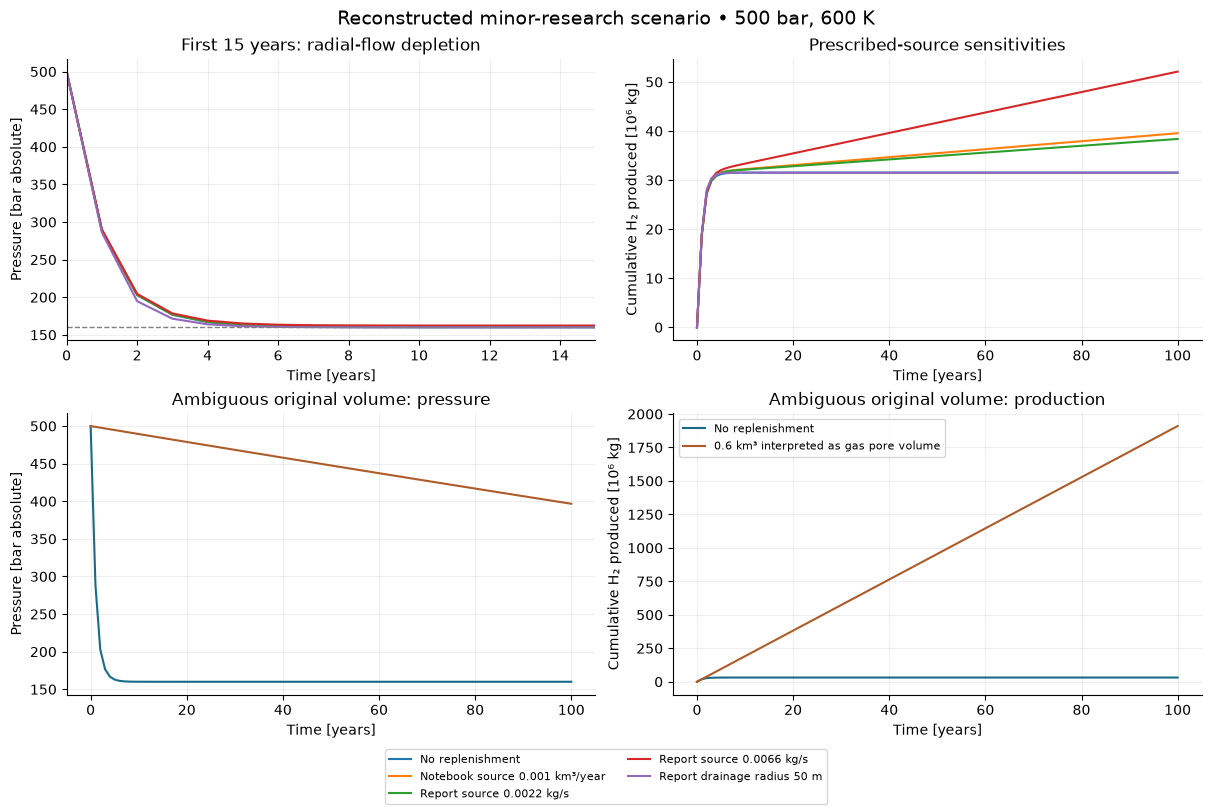

In [3]:
minor_results, minor_verification = run_minor_scenarios()
print('Physical gas pore volume:', f"{minor_verification['gas_pore_volume_m3']:,.0f} m³")
print('Derived bulk rock volume:', f"{minor_verification['derived_bulk_volume_m3']:,.0f} m³")
print('Consistent drainage radius:', f"{minor_verification['derived_drainage_radius_m']:.2f} m")
for name, result in minor_results.items():
    print(f'{name}: final pressure {result.pressure_bar[-1]:.3f} bar; '
          f'produced {result.cumulative_produced_kg[-1]/1e6:.3f} million kg; '
          f'mass balance {result.relative_balance_error:.2e}')
minor_figure = make_minor_figure(minor_results)
plt.show()

## Comparison geometry for the companion DARTS model

This separate example has **1 km × 1 km × 30 m** bulk rock, porosity **0.15**, and initial gas saturation **0.8**, giving **3.6 million m³** gas pore volume. Start at **100 bar and 330 K**, with BHP **30 bar** and target **100,000 Sm³/day**. Here standard conditions are **288.15 K and 1.01325 bar**. The simple deliverability coefficient is an uncalibrated **25 Sm³/day/bar²**; it does not reproduce a DARTS well index.

The tank and DARTS curves should not generally agree: the tank has uniform pressure and fixed gas volume; DARTS resolves pressure gradients and gas–water movement. Exact comparisons are appropriate only in carefully matched closed/immobile-water or ideal-gas limits. With replenishment, production divided by initial inventory may exceed 1; that does not mean more than 100% of the original molecules were recovered.

{
  "duration_days": 3652.5,
  "initial_mass_kg": 25050550.472186603,
  "final_mass_kg": 9430917.029567307,
  "final_pressure_bar": 36.37294967035632,
  "produced_kg": 15619633.442619214,
  "source_kg": 0.0,
  "leaked_kg": 0.0,
  "consumed_kg": 0.0,
  "produced_fraction_of_initial_inventory": 0.6235245592691286,
  "max_balance_residual_kg": 8.475035429000854e-08,
  "relative_balance_error": 3.3831733312250398e-15,
  "rhs_evaluations": 5261
}


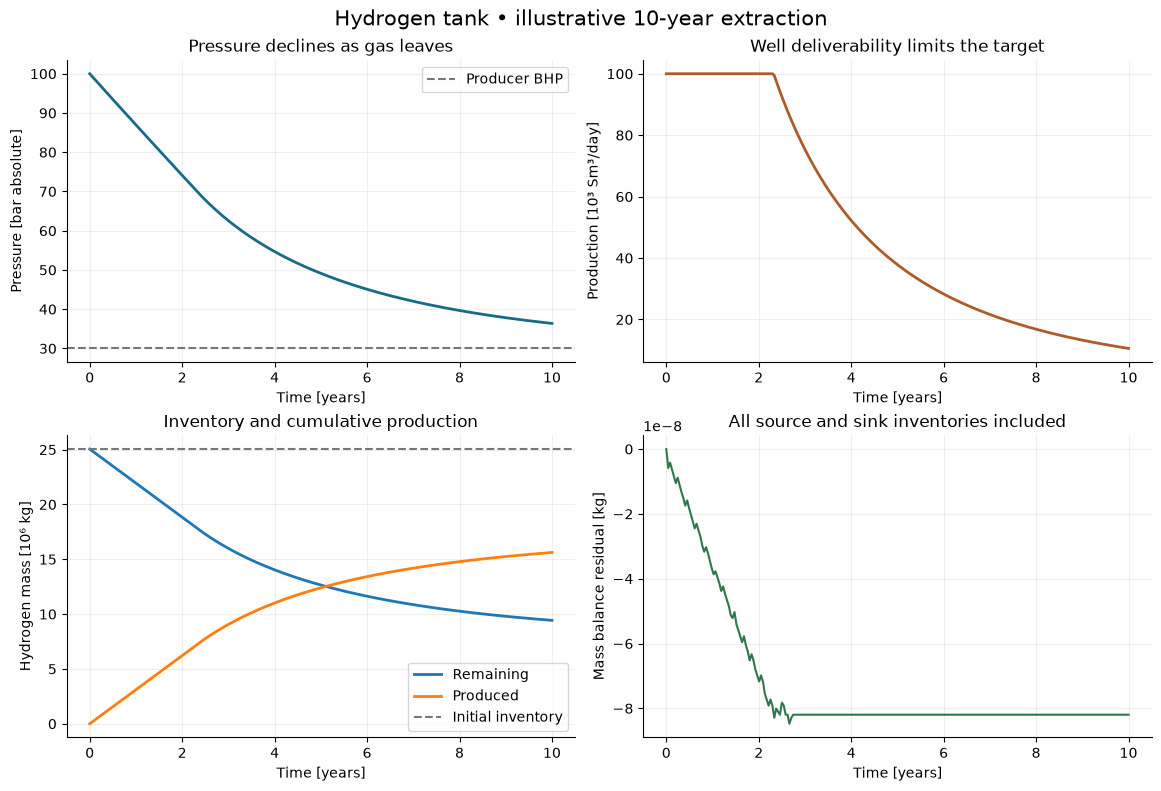

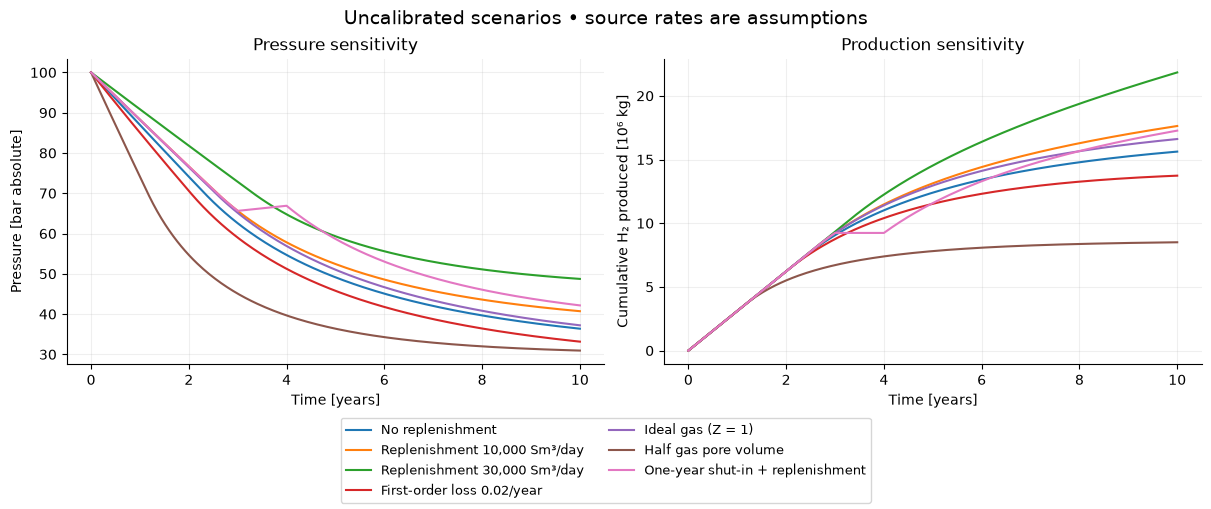

In [4]:
config, scenarios, verification = run_examples()
baseline = scenarios['No replenishment']
print(json.dumps(baseline.summary(), indent=2))
figures = make_figures(scenarios)
plt.show()

## Edit a physically declared input

Use dataclasses to create new cases without changing hidden global variables. This example uses the same initial tank but inserts a one-year shut-in. All rates are standard m³/day at the default reference conditions. A prescribed source continues during shut-in, so the model may recover pressure. Natural generation, long-range migration, and engineered injection cannot be distinguished by this lumped balance alone.

In [5]:
custom_schedule = [
    OperatingStage(3*365.25, production_target_sm3_day=100_000, source_sm3_day=10_000, label='Produce'),
    OperatingStage(365.25, source_sm3_day=10_000, label='Shut in'),
    OperatingStage(6*365.25, production_target_sm3_day=100_000, source_sm3_day=10_000, label='Restart'),
]
custom = simulate(config, custom_schedule, sample_interval_days=15)
print('Final pressure:', round(custom.pressure_bar[-1], 3), 'bar')
print('Cumulative input:', round(custom.cumulative_source_kg[-1]), 'kg')
print('Cumulative production:', round(custom.cumulative_produced_kg[-1]), 'kg')
print('Final mass balance residual:', custom.balance_residual_kg[-1], 'kg')

Final pressure: 42.156 bar
Cumulative input: 3112104 kg
Cumulative production: 17266575 kg
Final mass balance residual: 5.21540641784668e-08 kg


## Independent checks

The tests compare against published NIST values, the ideal gas material balance for constant inflow/outflow, exact exponential first-order loss, and the analytical constant-viscosity radial gas-flow integral. They also verify shut-in controls, the production BHP limit, domain checks, and step refinement. Conservation alone would not validate the physical assumptions; these independent cases catch unit and equation errors.

In [6]:
import unittest
import test_tank_model
suite = unittest.defaultTestLoader.loadTestsFromModule(test_tank_model)
test_result = unittest.TextTestRunner(verbosity=1).run(suite)
assert test_result.wasSuccessful()
print('Baseline maximum pressure change after timestep refinement:',
      verification['max_pressure_refinement_difference_bar'], 'bar')
print('Largest scenario relative mass balance residual:',
      verification['maximum_scenario_relative_mass_balance_error'])

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 11 tests in 1.203s

OK


Baseline maximum pressure change after timestep refinement: 2.1357578816605383e-08 bar
Largest scenario relative mass balance residual: 5.555662204548484e-15


## Save reusable results

These files are the retained outputs; all assembly and notebook-execution scratch files are outside the project and removed after verification. The standalone `run_tank.py` reproduces the same result set. Tables label all units; mass balance residuals are included.

In [7]:
OUTPUT_DIR = TANK_DIR / 'output'
save_results(OUTPUT_DIR, scenarios, verification, figures)
minor_results['No replenishment'].to_csv(OUTPUT_DIR / 'minor_research_baseline.csv')
minor_figure.savefig(OUTPUT_DIR / 'minor_research_sensitivity.png', dpi=170)
(OUTPUT_DIR / 'minor_research_verification.json').write_text(json.dumps(minor_verification, indent=2) + '\n')
print('Saved:', OUTPUT_DIR)
print('Files:', ', '.join(path.name for path in sorted(OUTPUT_DIR.iterdir())))

Saved: /Users/sanderbertdacosta/Library/CloudStorage/OneDrive-Persoonlijk/Documenten/TU Delft/master/year 2/reservoir simulation/white_hydrogen/tank/output
Files: minor_research_baseline.csv, minor_research_sensitivity.png, minor_research_verification.json, tank_baseline.csv, tank_baseline.png, tank_sensitivity.csv, tank_sensitivity.png, verification.json


## Scope and next steps

The model assumes pure hydrogen, isothermal conditions, rigid pore space, and uniform pressure. It omits dissolution, capillary pressure, relative permeability, water influx/production, rock mechanics, heat transport, diffusion, and gas mixing. A first-order loss removes hydrogen from this model and records that removed mass; it does not predict reaction products or elemental balances. Radial well capacities assume steady flow and independent drainage; constant viscosity is an input, not a PVT prediction.

The companion **DARTS gas–water model** addresses spatial flow and adapts a natural-gas-style reservoir setup to hydrogen. To turn either screening model into a site forecast, supply measured pore volume, pressure/temperature, gas composition, permeability/relative permeability, well tests, boundary conditions, and replenishment constraints.

**Sources:** your `minor formation of hydrogen.docx`, §5 and Appendix 2; your `programming for tank model/Tank_model.ipynb`; and [Lemmon, Huber & Leachman (2008), revised hydrogen-density correlation, Eq. 3/Tables 1–2](https://tsapps.nist.gov/publication/get_pdf.cfm?pub_id=832233). The density correlation's stated range is not validation of the reservoir model or its input assumptions.